# Q-learning swing-up of the unbalanced disk — RBF parameterisation

Parameterised Q-learning with **Radial Basis Function (RBF) features** that learns to swing the disk up and balance it at the top, trained in simulation (`UnbalancedDisk`) and deployable on the real setup via `runExp.py`.

## Why RBF instead of a Q-table?

| | Tabular | RBF (this notebook) |
|---|---|---|
| State representation | discrete bins | continuous, no rounding |
| Parameters to learn | ~9 000+ Q-values | **1 104** (92 weights × 12 actions) |
| Generalisation | zero (each cell independent) | yes — nearby states share information |
| Memory of best model | full Q-dict (~MB) | 12 × 92 float array (~9 KB) |

**How it works:**  
The continuous state `[theta, omega]` is mapped to a 92-dimensional feature vector `phi(x)` made of 91 Gaussian bumps (placed over a grid of angle × velocity centres, denser near the top and bottom) plus a bias term. For each of the 12 discrete voltage actions a separate weight vector `theta_a` is learned, so:

$$\hat{Q}(x, u_a) = \boldsymbol{\theta}_a^\top \boldsymbol{\phi}(x)$$

The TD(0) update is a simple gradient step on the squared Bellman error:

$$\boldsymbol{\theta}_a \leftarrow \boldsymbol{\theta}_a + \alpha \cdot \delta \cdot \boldsymbol{\phi}(x)$$

where $\delta = r + \gamma \max_{a'} \hat{Q}(x', u_{a'}) - \hat{Q}(x, u_a)$ is the TD error.

**Notebook layout**
1. Imports & global configuration
2. Wrappers, RBF feature map & helpers
3. `Qlearn_RBF` — the training loop
4. Training-schedule plot
5. Training
6. Training-reward plot
7. Evaluation (deterministic, fixed start at the bottom)

In [1]:
#  Imports & global configuration
import sys
import os
import pickle
import time
import warnings
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces, Wrapper

warnings.filterwarnings("ignore")

# --- path ---
sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete import UnbalancedDisk

# Environment hyperparameters
DT              = 0.025   # simulation timestep (s)
UMAX            = 3.0     # maximum control voltage (V)

# RBF feature-map hyperparameters
# Angle centres: dense near top (phi~0) and bottom (phi~±π), coarse in between
PHI_CENTERS_TOP    = np.linspace(-0.4, 0.4, 5)           # fine zone around top
PHI_CENTERS_MID    = np.array([-1.6, -0.9, 0.9, 1.6])    # mid-range
PHI_CENTERS_BOT    = np.array([-np.pi, -2.5, 2.5, np.pi]) # bottom zone
PHI_CENTERS        = np.sort(np.unique(
    np.concatenate([PHI_CENTERS_TOP, PHI_CENTERS_MID, PHI_CENTERS_BOT])
))                                                         # 13 angle centres
OMEGA_CENTERS      = np.linspace(-5, 5, 7)                # 7 velocity centres
RBF_SIGMA_PHI      = 0.55   # Gaussian width in the angle direction  (rad)
RBF_SIGMA_OMEGA    = 2.0    # Gaussian width in the velocity direction (rad/s)
# Total features: 13 × 7 = 91 RBF bumps + 1 bias = 92
N_FEATURES         = len(PHI_CENTERS) * len(OMEGA_CENTERS) + 1

# Training hyperparameters
NSTEPS          = 380_000 # total training steps
MAX_EP_STEPS    = 300     # max steps per episode
ALPHA           = 0.10    # initial learning rate (slightly lower than tabular; LFA updates share)
GAMMA           = 0.99    # discount factor
AVG_WINDOW      = 8       # moving-average window for checkpointing
CALLBACK_FREQ   = 5_000   # steps between optional callback calls

# Evaluation hyperparameters
NUM_EVAL_EPS    = 50      # number of greedy evaluation episodes
EVAL_SEED       = 0       # fixed seed for reproducibility
TOP_TOL         = 0.30    # angular tolerance for "at top" (rad, ~17°)
NUM_WATCH_EPS   = 3       # episodes to render visually

# Checkpoint  (stores the 12×N_FEATURES weight matrix, not a Q-dict)
CHECKPOINT      = 'Q_learning_RBF_v1.pkl'

print(f"RBF feature vector size : {N_FEATURES}  (91 bumps + 1 bias)")
print(f"Total learnable weights : {6 * N_FEATURES}  (6 actions × {N_FEATURES})")
print(f"Tabular equivalent      : ~9 000+ Q-values")

RBF feature vector size : 92  (91 bumps + 1 bias)
Total learnable weights : 552  (6 actions × 92)
Tabular equivalent      : ~9 000+ Q-values


In [2]:
#  Environment wrappers, RBF feature map & helper utilities

class UnbalancedDiskResetWrapper(gym.Wrapper):
    """Normalise ``reset()`` across Gymnasium versions.

    Older builds of the environment return only ``obs``; newer ones return
    ``(obs, info)``.  This wrapper always returns ``(obs, info)``.
    """

    def __init__(self, env):
        super().__init__(env)

    def reset(self, *, seed=None, options=None):
        try:
            obs, info = self.env.reset(seed=seed)
        except TypeError:
            obs, info = self.env.reset(), {}
        return obs, info


# ---------------------------------------------------------------------------
# RBF feature map
# ---------------------------------------------------------------------------

# Pre-compute centre grid as (N_BUMPS, 2) array for fast vectorised evaluation
_phi_grid, _omega_grid = np.meshgrid(PHI_CENTERS, OMEGA_CENTERS, indexing='ij')
RBF_CENTERS = np.column_stack([_phi_grid.ravel(), _omega_grid.ravel()])  # (91, 2)


def _wrap_angle(theta):
    """Wrap theta (any range) so that 0 = top position, ±π = bottom.

    The environment uses theta=π as the top.  We remap so the top sits at
    phi=0, which is the natural centre of the RBF grid.
    """
    return ((theta - np.pi + np.pi) % (2 * np.pi)) - np.pi


def rbf_features(obs):
    """Map a continuous ``[theta, omega]`` observation to the RBF feature vector.

    Parameters
    ----------
    obs : array-like of shape (2,)
        Raw continuous ``[theta, omega]`` from the environment.

    Returns
    -------
    phi : np.ndarray of shape (N_FEATURES,)
        Feature vector: 91 Gaussian bumps followed by a bias term of 1.0.

    Notes
    -----
    The angle is wrapped to [-π, π] around the top (phi=0) before computing
    distances so that the RBF grid is centred on the balance target and the
    Gaussians do not straddle the angle discontinuity at ±π.
    """
    phi_val   = _wrap_angle(float(obs[0]))
    omega_val = float(obs[1])
    state     = np.array([phi_val, omega_val])

    # Scaled squared distances from every centre
    diff = state - RBF_CENTERS                    # (91, 2)
    d2   = (diff[:, 0] / RBF_SIGMA_PHI  ) ** 2 \
         + (diff[:, 1] / RBF_SIGMA_OMEGA) ** 2   # (91,)
    bumps = np.exp(-0.5 * d2)                     # (91,)

    return np.append(bumps, 1.0)                  # (92,)  — bias last


# ---------------------------------------------------------------------------
# Helper utilities
# ---------------------------------------------------------------------------

def roll_mean(ar, start=2000, N=50):
    """Exponential moving average of array *ar*.

    Parameters
    ----------
    ar : np.ndarray
        Input signal.
    start : float
        Initial value of the accumulator.
    N : int
        Smoothing horizon; larger values produce a smoother output.

    Returns
    -------
    np.ndarray
        Same shape as *ar*.
    """
    s = 1 - 1 / N
    k = start
    out = np.zeros(ar.shape)
    for i, a in enumerate(ar):
        k = s * k + (1 - s) * a
        out[i] = k
    return out


def argmax(a):
    """Return the index of the maximum, breaking ties uniformly at random.

    Avoids the systematic bias of ``np.argmax``, which always picks the
    first maximum.
    """
    a = np.array(a)
    return np.random.choice(np.arange(len(a), dtype=int)[a == np.max(a)])

In [3]:
#  Parameterised Q-learning with RBF features

def Qlearn_RBF(env, nsteps=5000, callbackfreq=5000,
               alpha=0.10, gamma=0.99, avg_window=8,
               checkpoint_name='best_theta.pkl', callback=None):
    """Parameterised Q-learning for the continuous unbalanced-disk environment.

    Learns a weight matrix ``Theta`` of shape ``(n_actions, N_FEATURES)``
    where ``Theta[a] @ phi(x)`` approximates ``Q(x, a)``.
    The TD(0) update is a semi-gradient step on the squared Bellman error:

    .. code-block:: text

        delta      = r + gamma * max_a' Q(x', a') - Q(x, a)
        Theta[a]  += alpha * delta * phi(x)

    Three quantities anneal over *nsteps* (identical to the tabular notebook):

    .. code-block:: text

        epsilon        0.7·exp(-5z/nsteps) + 0.01,  floored at 0
        alpha_now      alpha·(1 - z/nsteps),          floored at 0.01
        start_scale    1 → 0.15

    A warm start is attempted if *checkpoint_name* already exists on disk.
    The checkpoint is overwritten whenever the moving average of the last
    *avg_window* episode returns reaches a new all-time high.

    Parameters
    ----------
    env : gym.Env
        Continuous (un-discretised) time-limited training environment.
    nsteps : int
        Total number of environment steps.
    callbackfreq : int
        How often (in steps) the optional *callback* is called.
    alpha : float
        Initial learning rate.
    gamma : float
        Discount factor.
    avg_window : int
        Number of recent episodes used for the moving-average checkpoint.
    checkpoint_name : str
        Path to the pickle file used for saving/loading the best Theta.
    callback : callable or None
        Optional ``callback(Theta, step, env)`` called every *callbackfreq* steps.

    Returns
    -------
    Theta : np.ndarray of shape (n_actions, N_FEATURES)
        Best weight matrix found (by moving-average reward).
    ep_lengths_steps : np.ndarray
        Training step at which each episode ended.
    ep_lengths : np.ndarray
        Length (steps) of each episode.
    ep_rewards : np.ndarray
        Total undiscounted return of each episode.
    """
    n_actions = env.action_space.n

    # Weight matrix: one row per action, one column per feature
    Theta = np.zeros((n_actions, N_FEATURES))

    # Locate the TimeLimit wrapper to read _elapsed_steps after each episode
    env_time = env
    while not isinstance(env_time, gym.wrappers.TimeLimit):
        if hasattr(env_time, 'env'):
            env_time = env_time.env
        else:
            print("Warning: no gym.wrappers.TimeLimit found; _elapsed_steps unavailable.")
            break

    ep_lengths, ep_lengths_steps, ep_rewards = [], [], []
    obs_raw, info = env.reset()
    phi_s = rbf_features(obs_raw)          # current feature vector
    current_episode_reward = 0.0
    ep_max_abs_th = 0.0
    best_avg_reward = -float('inf')
    best_Theta_to_save = None
    recent_rewards = deque(maxlen=avg_window)

    # Warm start: load existing checkpoint if present
    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Theta = pickle.load(f)
            print(f"Loaded initial Theta from '{checkpoint_name}'; continuing training.")
        except Exception as e:
            print(f"Warning: could not load '{checkpoint_name}': {e}. Starting fresh.")
    else:
        print(f"No checkpoint at '{checkpoint_name}'; starting from zero weights.")

    for z in range(nsteps):
        # Annealed exploration: decays to 0 so the final policy is deterministic
        eps       = (0.7 * np.exp(-5 * z / nsteps) + 0.01) * max(0.0, 1 - z / nsteps)
        # Annealed learning rate: large early, small late
        alpha_now = max(0.01, alpha * (1 - z / nsteps))
        # Curriculum: wide start distribution early -> near bottom-at-rest late
        env.unwrapped.start_scale = max(0.15, 1 - z / nsteps)

        # Q-values for the current state: dot product for each action
        q_values = Theta @ phi_s            # (n_actions,)

        # Epsilon-greedy action selection
        if np.random.uniform() < eps:
            action = env.action_space.sample()
        else:
            action = argmax(q_values)

        obs_new_raw, reward, terminated, truncated, info = env.step(action)
        phi_s_new = rbf_features(obs_new_raw)
        ep_max_abs_th = max(ep_max_abs_th, abs(env.unwrapped.th))
        current_episode_reward += reward

        if callback and z % callbackfreq == 0:
            callback(Theta, z, env)

        if terminated or truncated:
            # Terminal TD target: just the reward (no next-state bootstrap)
            td_error = reward - float(Theta[action] @ phi_s)
            Theta[action] += alpha_now * td_error * phi_s

            ep_len = env_time._elapsed_steps   # read BEFORE reset clears it
            ep_lengths.append(ep_len)
            ep_lengths_steps.append(z)
            ep_rewards.append(current_episode_reward)
            recent_rewards.append(current_episode_reward)
            obs_raw, info = env.reset()
            phi_s = rbf_features(obs_raw)

            # Checkpoint when the moving average hits a new high
            if len(recent_rewards) == avg_window:
                running_avg = float(np.mean(recent_rewards))
                if running_avg > best_avg_reward:
                    best_avg_reward = running_avg
                    best_Theta_to_save = Theta.copy()
                    try:
                        with open(checkpoint_name, 'wb') as fpkl:
                            pickle.dump(best_Theta_to_save, fpkl)
                        print(
                            f"#################################\n"
                            f" NEW BEST AVG REWARD (last {avg_window} ep): "
                            f"{running_avg:.2f}, saved to '{checkpoint_name}'\n"
                            f"#################################"
                        )
                    except Exception as e:
                        print(f"Error saving Theta: {e}")

            max_deg = np.degrees(ep_max_abs_th)
            if   terminated:       tag = "FELL/SPUN"
            elif max_deg > 190:    tag = f"OVERSHOOT +{max_deg - 180:.0f} deg"
            elif max_deg > 165:    tag = "balanced ~top"
            else:                  tag = "stalled below"
            print(
                f"step {z+1:>7} | len {ep_len:>3} | "
                f"reward {current_episode_reward:>8.1f} | "
                f"max {max_deg:>4.0f} deg (top=180) | {tag}"
            )
            current_episode_reward = 0.0
            ep_max_abs_th = 0.0

        else:
            # Non-terminal: semi-gradient TD(0) update
            q_sa      = float(Theta[action] @ phi_s)
            best_next = float(np.max(Theta @ phi_s_new))
            td_error  = reward + gamma * best_next - q_sa
            Theta[action] += alpha_now * td_error * phi_s
            phi_s = phi_s_new

    # Return the best checkpoint
    if os.path.exists(checkpoint_name):
        try:
            with open(checkpoint_name, 'rb') as f:
                Theta_final = pickle.load(f)
            print(f"Loading final best Theta (avg reward {best_avg_reward:.2f}) from '{checkpoint_name}'.")
            return Theta_final, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
        except Exception as e:
            print(f"Error loading final Theta: {e}. Returning current Theta.")
    elif best_Theta_to_save is not None:
        print("No checkpoint file found; returning best in-memory Theta.")
        return best_Theta_to_save, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)
    else:
        print("No best Theta was saved; returning the current Theta.")

    return Theta, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)

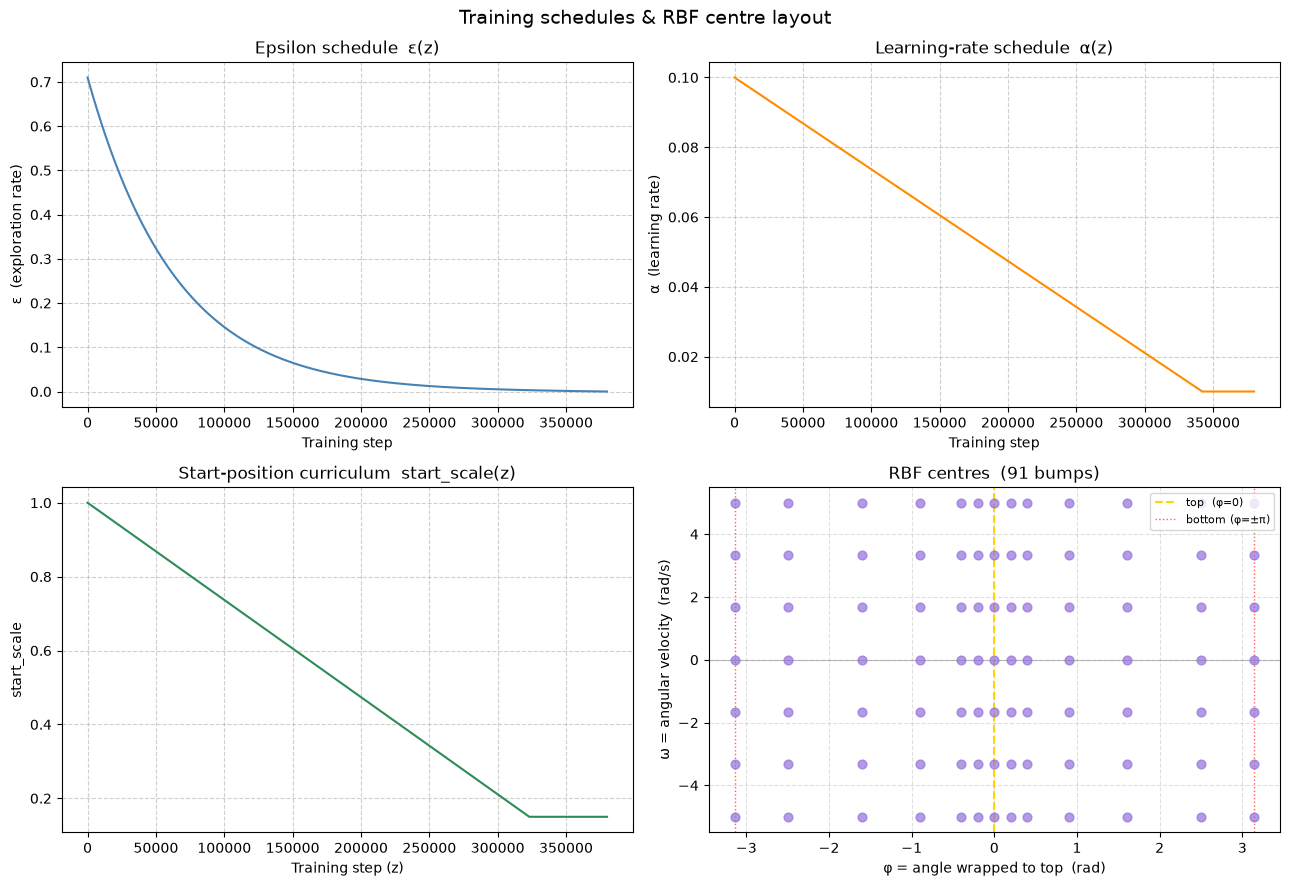

In [4]:
#  Training schedule visualisation
#  Shows how epsilon, alpha, start_scale, and the RBF centres evolve / are laid out.

z_arr     = np.arange(NSTEPS)
eps_arr   = (0.7 * np.exp(-5 * z_arr / NSTEPS) + 0.01) * np.maximum(0.0, 1 - z_arr / NSTEPS)
alpha_arr = np.maximum(0.01, ALPHA * (1 - z_arr / NSTEPS))
start_arr = np.maximum(0.15, 1 - z_arr / NSTEPS)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Training schedules & RBF centre layout", fontsize=14)

axes[0, 0].plot(z_arr, eps_arr, color='steelblue')
axes[0, 0].set_ylabel("ε  (exploration rate)")
axes[0, 0].set_title("Epsilon schedule  ε(z)")
axes[0, 0].set_xlabel("Training step")
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

axes[0, 1].plot(z_arr, alpha_arr, color='darkorange')
axes[0, 1].set_ylabel("α  (learning rate)")
axes[0, 1].set_title("Learning-rate schedule  α(z)")
axes[0, 1].set_xlabel("Training step")
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

axes[1, 0].plot(z_arr, start_arr, color='seagreen')
axes[1, 0].set_ylabel("start_scale")
axes[1, 0].set_title("Start-position curriculum  start_scale(z)")
axes[1, 0].set_xlabel("Training step (z)")
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# RBF centre layout
ax = axes[1, 1]
ax.scatter(RBF_CENTERS[:, 0], RBF_CENTERS[:, 1],
           s=40, color='mediumpurple', alpha=0.7, zorder=3)
ax.axvline(0,    color='gold',      lw=1.5, linestyle='--', label='top  (φ=0)')
ax.axvline(np.pi, color='tomato',   lw=1.0, linestyle=':',  label='bottom (φ=±π)')
ax.axvline(-np.pi, color='tomato',  lw=1.0, linestyle=':')
ax.axhline(0,    color='grey',      lw=0.8, linestyle='-',  alpha=0.5)
ax.set_xlabel("φ = angle wrapped to top  (rad)")
ax.set_ylabel("ω = angular velocity  (rad/s)")
ax.set_title(f"RBF centres  ({len(RBF_CENTERS)} bumps)")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [5]:
#  Training
print("\n--- START TRAINING (RBF parameterised Q-learning) ---")

# No Discretize_obs wrapper needed — we pass raw continuous observations to rbf_features()
env_train = UnbalancedDisk(dt=DT, umax=UMAX, render_mode=None)
env_train = UnbalancedDiskResetWrapper(env_train)
env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=MAX_EP_STEPS)

Theta_trained, ep_lengths_steps, ep_lengths, ep_rewards = Qlearn_RBF(
    env_train,
    nsteps=NSTEPS,
    callbackfreq=CALLBACK_FREQ,
    alpha=ALPHA,
    gamma=GAMMA,
    avg_window=AVG_WINDOW,
    checkpoint_name=CHECKPOINT,
)
env_train.close()

# Verify checkpoint
if os.path.exists(CHECKPOINT):
    print(f"\nCheckpoint '{CHECKPOINT}' found on disk.")
    with open(CHECKPOINT, 'rb') as f:
        _check = pickle.load(f)
    print(f"Loaded for verification: Theta shape = {_check.shape}  "
          f"({_check.shape[0]} actions × {_check.shape[1]} features)")
else:
    print(f"\nWarning: checkpoint '{CHECKPOINT}' not found on disk.")


--- START TRAINING (RBF parameterised Q-learning) ---
No checkpoint at 'Q_learning_RBF_v1.pkl'; starting from zero weights.
step     300 | len 300 | reward    -93.4 | max   82 deg (top=180) | stalled below
step     600 | len 300 | reward    -89.4 | max   71 deg (top=180) | stalled below
step     900 | len 300 | reward    -54.2 | max  115 deg (top=180) | stalled below
step    1200 | len 300 | reward    -73.5 | max   96 deg (top=180) | stalled below
step    1500 | len 300 | reward    -83.8 | max   62 deg (top=180) | stalled below
step    1800 | len 300 | reward    -64.9 | max  102 deg (top=180) | stalled below
step    2100 | len 300 | reward    -66.7 | max  110 deg (top=180) | stalled below
#################################
 NEW BEST AVG REWARD (last 8 ep): -76.83, saved to 'Q_learning_RBF_v1.pkl'
#################################
step    2400 | len 300 | reward    -88.7 | max   80 deg (top=180) | stalled below
#################################
 NEW BEST AVG REWARD (last 8 ep): -72.54, 

Last 10 episode rewards: [-7.41110845 -0.29300284 -6.48536026 -2.02041414 -4.48383538 -9.12060899
 -1.15738094 -2.64173847 -8.96672768 -7.59357259]


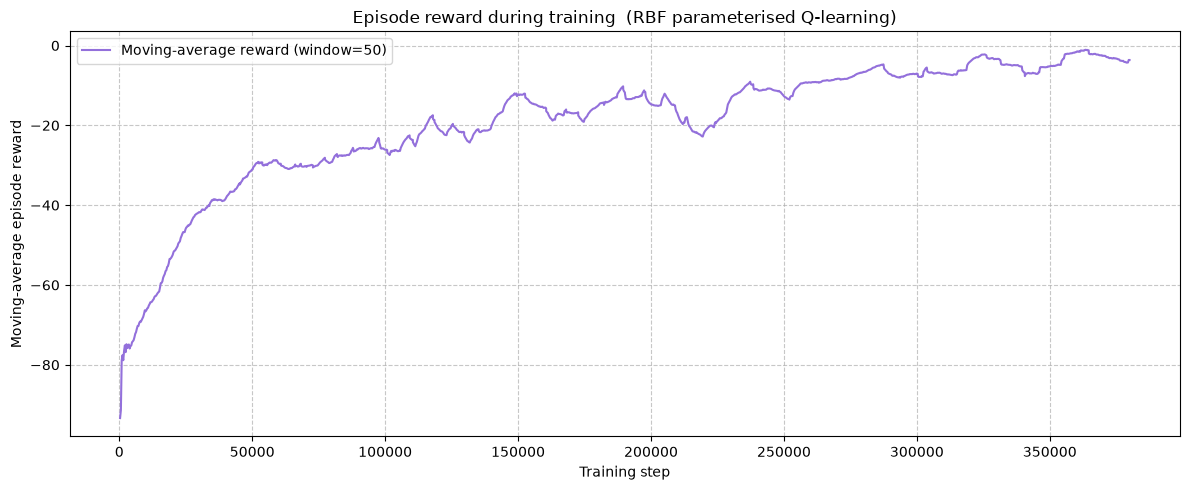

In [6]:
#  Training reward curve

N_ROLLING = 50
rolled = [
    np.mean(ep_rewards[max(0, i - N_ROLLING + 1): i + 1])
    for i in range(len(ep_rewards))
]

print(f"Last 10 episode rewards: {ep_rewards[-10:]}")

plt.figure(figsize=(12, 5))
plt.plot(ep_lengths_steps, rolled,
         label=f"Moving-average reward (window={N_ROLLING})", color='mediumpurple')
plt.xlabel("Training step")
plt.ylabel("Moving-average episode reward")
plt.title("Episode reward during training  (RBF parameterised Q-learning)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
#  Greedy evaluation with best checkpoint

print("\n--- START EVALUATION WITH BEST MODEL (RBF) ---")


def make_eval_env(render_mode):
    """Build the evaluation environment stack (no curriculum, no discretisation)."""
    e = UnbalancedDisk(dt=DT, umax=UMAX, render_mode=render_mode)
    e = UnbalancedDiskResetWrapper(e)
    e = gym.wrappers.TimeLimit(e, max_episode_steps=MAX_EP_STEPS)
    return e


def greedy_action_rbf(Theta, obs_raw):
    """Select the greedy action given the weight matrix and a raw continuous obs."""
    phi = rbf_features(obs_raw)
    return int(np.argmax(Theta @ phi))


def run_episode(env, Theta, start=(0.0, 0.0), render=False, fps=30):
    """Run one greedy episode from a fixed start state.

    Parameters
    ----------
    env : gym.Env
        Continuous evaluation environment.
    Theta : np.ndarray of shape (n_actions, N_FEATURES)
        Learned weight matrix.
    start : tuple of float
        ``(theta, omega)`` initial state forced before ``env.reset()``.
    render : bool
        Whether to call ``env.render()`` each step.
    fps : int
        Target rendering frame rate (used only when *render* is True).

    Returns
    -------
    total_r : float
        Undiscounted episode return.
    steps : int
        Episode length in steps.
    top_frac : float
        Fraction of steps spent within *TOP_TOL* of the top position.
    ended_at_top : bool
        Whether the final state was within *TOP_TOL* of the top.
    """
    base = env.unwrapped
    base.set_th, base.set_omega = float(start[0]), float(start[1])
    obs_raw, info = env.reset()
    base.set_th, base.set_omega = None, None   # restore default reset behaviour

    total_r, steps, done, top_steps = 0.0, 0, False, 0
    while not done:
        action = greedy_action_rbf(Theta, obs_raw)
        obs_raw, reward, terminated, truncated, info = env.step(action)
        total_r += reward
        steps   += 1
        done     = terminated or truncated

        err_top = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        if err_top < TOP_TOL:
            top_steps += 1

        if render:
            env.render()
            time.sleep(1 / fps)

    err_top_final = abs(((base.th - np.pi + np.pi) % (2 * np.pi)) - np.pi)
    ended_at_top  = err_top_final < TOP_TOL
    return total_r, steps, top_steps / max(steps, 1), ended_at_top


# Load best Theta
best_Theta = None
if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT, 'rb') as f:
        best_Theta = pickle.load(f)
    print(f"Loaded best Theta from '{CHECKPOINT}'  shape={best_Theta.shape}.")
else:
    print(f"Error: checkpoint '{CHECKPOINT}' not found. Run training first.")

if best_Theta is not None:
    START = (0.0, 0.0)   # disk at rest at the bottom

    # ── Statistical evaluation (no render) ──────────────────────────────────
    np.random.seed(EVAL_SEED)
    env_stats = make_eval_env(render_mode=None)
    rewards, lengths, toptime, ended = [], [], [], []
    for _ in range(NUM_EVAL_EPS):
        r, l, ft, et = run_episode(env_stats, best_Theta, start=START)
        rewards.append(r); lengths.append(l); toptime.append(ft); ended.append(et)
    env_stats.close()

    rewards  = np.array(rewards)
    lengths  = np.array(lengths)
    toptime  = np.array(toptime)

    print(f"\n--- EVALUATION RESULTS ({NUM_EVAL_EPS} greedy episodes, fixed start at bottom) ---")
    print(f"Reward      : mean {rewards.mean():8.2f} | std {rewards.std():7.2f} | "
          f"median {np.median(rewards):8.2f} | min {rewards.min():8.2f} | max {rewards.max():8.2f}")
    print(f"Length      : mean {lengths.mean():8.1f} | min {int(lengths.min())} | max {int(lengths.max())}")
    print(f"Time at top : mean {100*toptime.mean():5.1f}%   ← primary quality metric")
    print(f"Success     : {100*np.mean(ended):5.1f}% of episodes ended at the top")

    # ── Visual evaluation (rendered) ────────────────────────────────────────
    np.random.seed(EVAL_SEED)
    env_watch = make_eval_env(render_mode='human')
    for i in range(NUM_WATCH_EPS):
        r, l, ft, et = run_episode(env_watch, best_Theta, start=START, render=True)
        print(f"Watch episode {i+1}: length={l}, reward={r:.2f}, time-at-top={100*ft:.0f}%")
    env_watch.close()

else:
    print("No best Theta available for evaluation.")


--- START EVALUATION WITH BEST MODEL (RBF) ---
Loaded best Theta from 'Q_learning_RBF_v1.pkl'  shape=(6, 92).

--- EVALUATION RESULTS (50 greedy episodes, fixed start at bottom) ---
Reward      : mean    -5.64 | std    0.98 | median    -5.81 | min    -6.53 | max    -3.71
Length      : mean    300.0 | min 300 | max 300
Time at top : mean   0.0%   ← primary quality metric
Success     :   0.0% of episodes ended at the top
Watch episode 1: length=300, reward=-5.09, time-at-top=0%
Watch episode 2: length=300, reward=-6.53, time-at-top=0%
Watch episode 3: length=300, reward=-5.09, time-at-top=0%
